# Test Description
**This notebook reproduces the results from section 5.1 of the paper "Multisensor Track-to-Track Association for Tracks with Dependent Errors" by Y. Bar-Shalom**

## Goal
The goal of this trial is to compute the true and false positive rates of associations when using the likelihood ratio as a scoring mechanism for potential track associations. 

## Test Parameters
We will run a set of monte-carlo simulations over the paremeters $rho$ and $N$, where 
- **$rho$** is the cross correlation between decentralized sensor's tracking errors.
- **N** is the number of real tracks, and, under the assumption that probability of detection $P_D = 1$ for all sensors, is also the number of track estimates in each sensor's track list.

## Methods
The method for generating test data is not well described in the the paper. The paper's only detail is that 1000 realizations are created for each of two hypothesis described below:

| Hypothesis | Definition |
|---|---|
| $H_0$ | All tracks in the candidate group are associated with the same real object |
| $H_1$ | One or more of the tracks in the candidate group does not share the same real object source |

To create these realizations and generate the ROC curves displayed in the paper, we do the following:

<ol style="list-style-type: decimal;">
    <li>Generate 1000 "true" states.</li>
    <li>For each fixed pair $(\rho, N)$:
        <ol style="list-style-type: decimal;">
            <li>Generate $N \times 1000$ error values from a Gaussian with zero mean, unit variance and cross-covariance $\rho$.</li>
            <li>Utilizing Numpy's broadcasting capabilities, we add the error array to the true state array resulting in an array of shape <code>(n_trials = 1000, n_tracks = N, n_states = 1)</code>.</li>
            <li>The resulting array gives us our true associations along the second dimension. These are our 1000 realizations drawn from $H_0$.</li>
            <li>In order to get 1000 realizations from $H_1$, we copy the previously described array and shift the tracks across Monte Carlo trials so that tracks grouped into the same candidate association no longer originate from the same true state</li>
            <li>We then score each invalid and valid association according to the likelihood function.</li>
            <li>Each score becomes a decision threshold below which the null hypothesis is discarded and above which it is kept.</li>
            <li>The true and false positive rates are calculated and the ROC curve is populated.</li>
        </ol>
    </li>
</ol>

## Expirment Code 
The code to perform this experiment is provided below in the collapsed Jupyter Notebook cells. You can click on the left margin to expand them. 

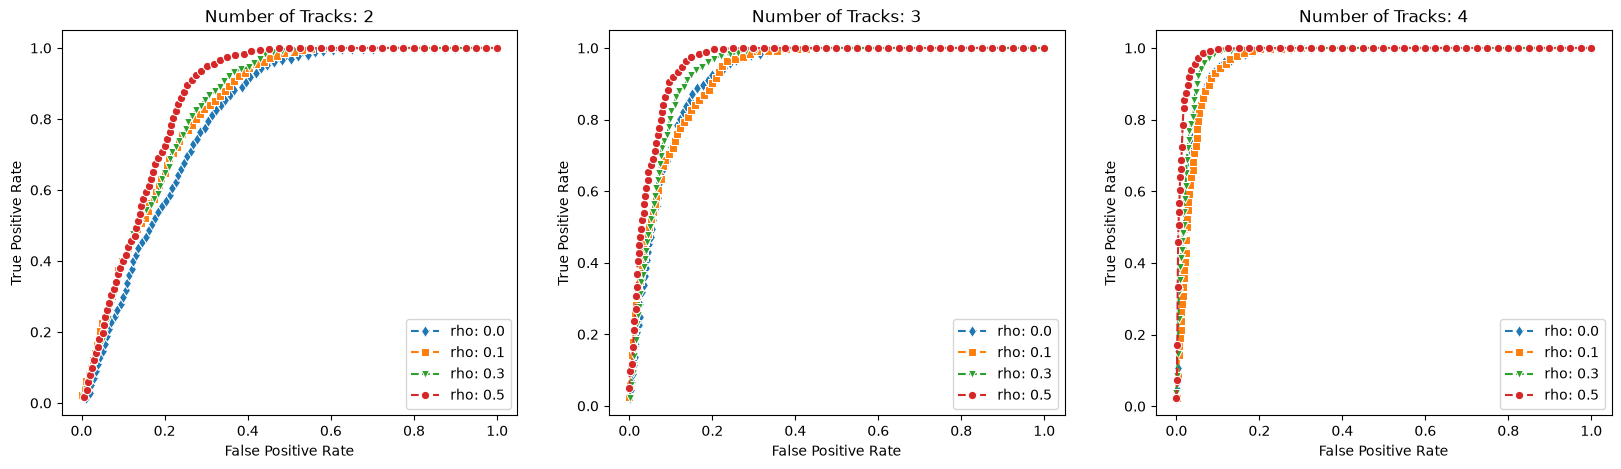

In [4]:
import numpy as np
from scipy.stats import multivariate_normal

import matplotlib.pyplot as plt
import seaborn as sns

true_states = np.random.uniform(-5, 5, 1000)[..., None]
true_states.shape # (n_trials, n_states)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

N = (2, 3, 4)             # number of local tracks, one from each sensor
rho = (0.0, .1, .3, .5)   # error correlation between sensors
markers = ['d', 's', 'v', 'o']

for r, m in zip(rho, markers): # for each correlation value
    for p, n in enumerate(N):  # for each number of local tracks

        # ---------------------------------------------------------------------------
        # ------------ 1. For each trial, generate one track per sensor -------------
        # We do this by generating the correlated errors and adding them to the true state
        # of the object of interest, as shown by equation 45/46 in the appendix.
        # ---------------------------------------------------------------------------

        # error cov shape (n_local_tracks, n_local_tracks)
        err_cov = np.full((n, n), r)
        np.fill_diagonal(err_cov, 1.0)

        # error shape: (n_trials, n_local_tracks, n_states)
        err = np.random.multivariate_normal(np.zeros(n), err_cov, size=1000)[..., None]

        # true_states + error --> (n_trials, n_local_tracks, n_states)
        tracks = true_states[:, None, :] + err

        # --------------------------------------------------------------------------
        # ----------- 2. Form candidate track associations -------------------------
        # NOTE: the track tensor can be used for valid associations. For example tracks[j, :]
        #       gives all local tracks associated with the object in trial j. So, we only
        #       need to form the invalid associations.
        # --------------------------------------------------------------------------

        # form 1000 S-Tuples of invalid associations
        invalid_associations = np.empty_like(tracks)
        for i in range(n):
            invalid_associations[:, i] = np.roll(tracks[:, i], i, axis=0)

        # --------------------------------------------------------------------------
        # --------- 3. Grade all associations with negative log likelihood ---------
        # --------------------------------------------------------------------------

        # form covariance matrix for measurement likelihood, described in eqns 13 and 14
        # ... vastly simplified by the assumption of scalar states and constant rho
        P = np.full((n - 1, n - 1), 1 - r)
        np.fill_diagonal(P, 2 * (1 - r))
        mvn = multivariate_normal(mean=np.zeros(n - 1), cov=P)

        # these are the likelihood function input vectors according to equation 12
        valid_diff = tracks[:, 1:] - tracks[:, 0, None] # (n_trials, n_local_tracks - 1, n_states)
        invalid_diff = invalid_associations[:, 1:] - invalid_associations[:, 0, None]

        valid_scores = mvn.pdf(valid_diff[..., 0])
        invalid_scores = mvn.pdf(invalid_diff[..., 0])

        scores = np.sort(np.concat([valid_scores, invalid_scores]))

        tprs = []
        fprs = []

        # Let each score serve as an operating point on the ROC curve, and compute the true/false positive rates at those points. 
        for t in scores[::25]:
            tprs.append((valid_scores > t).sum() / 1000)
            fprs.append((invalid_scores > t).sum() / 1000)

        # Plot the ROC curves
        a = sns.lineplot(
            x=fprs,
            y=tprs,
            linestyle="--",
            marker=m,
            label=f"rho: {r}",
            ax=ax[p]
        )
        
        a.legend(loc="lower right")

for i, a in enumerate(ax):
    a.set_title(f"Number of Tracks: {N[i]}")
    a.set_xlabel("False Positive Rate")
    a.set_ylabel("True Positive Rate")

plt.show()